C:\Users\Win11\AppData\Local\Temp\ipykernel_55312\2917735782.py:10: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  events = pd.read_csv('events.csv', parse_dates=['event_date'])


=== DATASET SUMMARY ===
Total trial users    : 5,000
Converted users      : 601
Overall conv. rate   : 12.0%
Date range           : 2025-01-01 00:00:00 to 2025-12-31 00:00:00

           trial_id      user_id    converted                 signup_date
count   5000.000000  5000.000000  5000.000000                        5000
mean    7500.500000  3500.500000     0.120200  2025-07-04 10:17:45.600000
min     5001.000000  1001.000000     0.000000         2025-01-01 00:00:00
25%     6250.750000  2250.750000     0.000000         2025-04-03 00:00:00
50%     7500.500000  3500.500000     0.000000         2025-07-05 00:00:00
75%     8750.250000  4750.250000     0.000000         2025-10-05 00:00:00
max    10000.000000  6000.000000     1.000000         2025-12-31 00:00:00
std     1443.520003  1443.520003     0.325228                         NaN


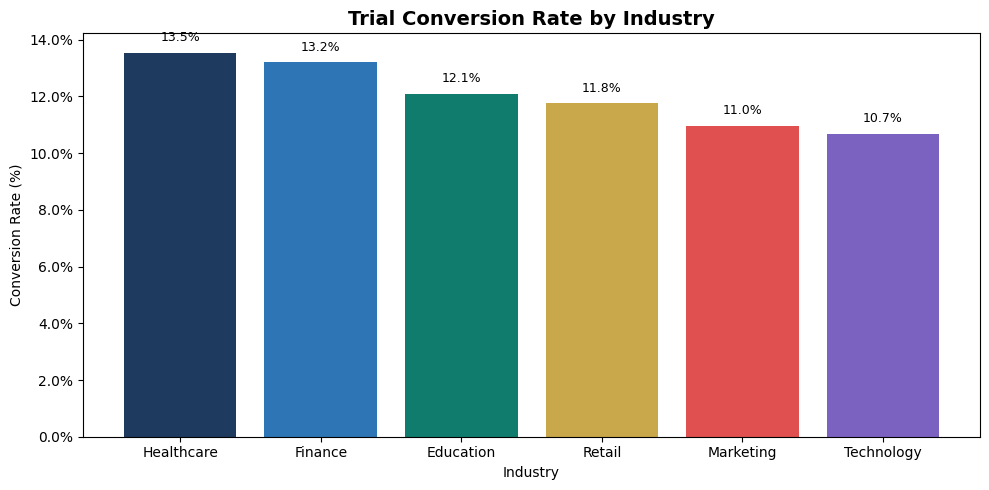


=== FUNNEL ANALYSIS ===
              Stage  Users  Pct_of_Top  Drop_Off
      Trial Started   5000       100.0       0.0
        First Login   3756        75.1      24.9
       Feature Used   3752        75.0       0.1
Invited Team Member   3822        76.4       1.4
  Created Dashboard   3776        75.5       0.9
  Converted to Paid    601        12.0      63.5


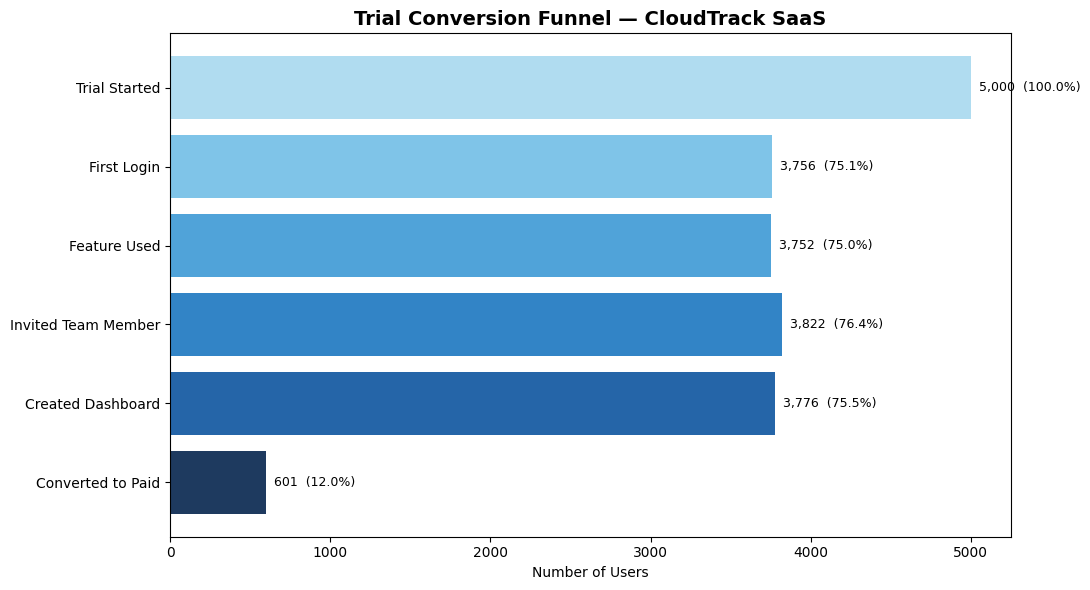

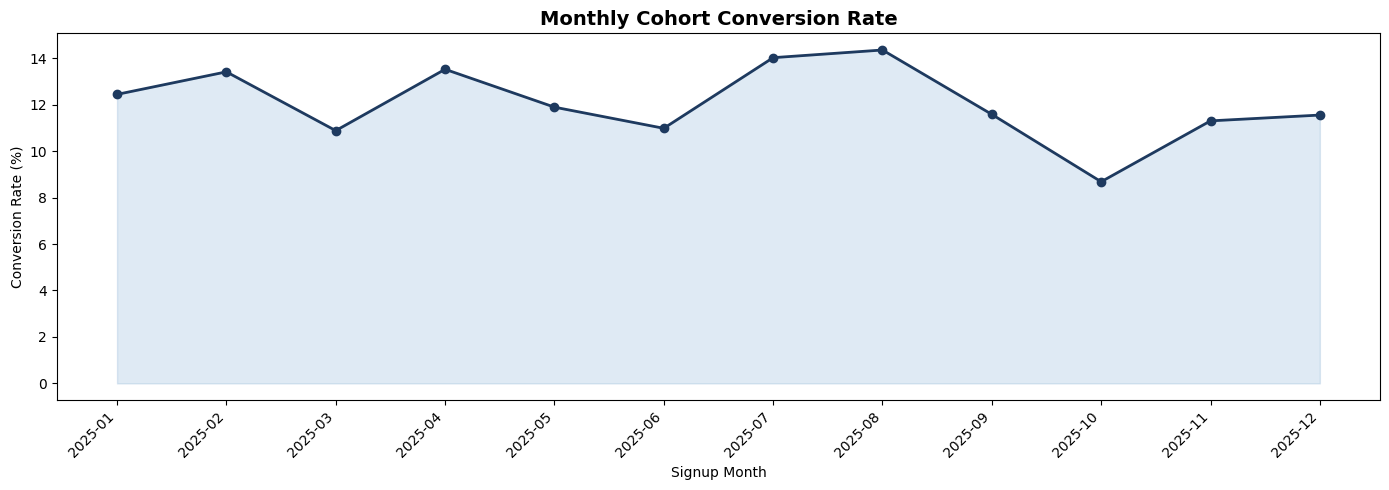

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────
users  = pd.read_csv('users.csv', parse_dates=['signup_date'])
trials = pd.read_csv('trials.csv', parse_dates=['trial_end_date','conversion_date'])
events = pd.read_csv('events.csv', parse_dates=['event_date'])
subs   = pd.read_csv('subscriptions.csv')
ab     = pd.read_csv('ab_test_results.csv')

df = trials.merge(users, on='user_id')

# ── 2. BASIC EDA ──────────────────────────────────────────────────────────
print('=== DATASET SUMMARY ===')
print(f'Total trial users    : {len(df):,}')
print(f'Converted users      : {df.converted.sum():,}')
print(f'Overall conv. rate   : {df.converted.mean()*100:.1f}%')
print(f'Date range           : {users.signup_date.min()} to {users.signup_date.max()}')
print()
print(df.describe())

# ── 3. CONVERSION BY INDUSTRY ─────────────────────────────────────────────
ind_conv = df.groupby('industry')['converted'].agg(['mean','count']).reset_index()
ind_conv.columns = ['industry','conv_rate','count']
ind_conv = ind_conv.sort_values('conv_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ind_conv['industry'], ind_conv['conv_rate']*100,
              color=['#1E3A5F','#2E75B6','#107C6E','#C9A84C','#E05050','#7B61C0'])
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Trial Conversion Rate by Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Industry'); ax.set_ylabel('Conversion Rate (%)')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_conv_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. FUNNEL CHART ───────────────────────────────────────────────────────
stages = {
    'Trial Started'       : df['user_id'].nunique(),
    'First Login'         : events[events.event_type=='login']['user_id'].nunique(),
    'Feature Used'        : events[events.event_type=='feature_used']['user_id'].nunique(),
    'Invited Team Member' : events[events.event_type=='invite_sent']['user_id'].nunique(),
    'Created Dashboard'   : events[events.event_type=='dashboard_created']['user_id'].nunique(),
    'Converted to Paid'   : int(df['converted'].sum()),
}

funnel = pd.DataFrame(list(stages.items()), columns=['Stage','Users'])
funnel['Pct_of_Top'] = (funnel['Users'] / funnel['Users'].iloc[0] * 100).round(1)
funnel['Drop_Off']   = funnel['Pct_of_Top'].diff().fillna(0).abs()
print('\n=== FUNNEL ANALYSIS ===')
print(funnel.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#1E3A5F','#2565A8','#3284C6','#50A3D9','#7FC4E8','#B0DCF0']
bars = ax.barh(funnel['Stage'][::-1], funnel['Users'][::-1], color=colors)
for b, row in zip(bars, funnel[::-1].itertuples()):
    ax.text(b.get_width()+50, b.get_y()+b.get_height()/2,
            f'{row.Users:,}  ({row.Pct_of_Top}%)', va='center', fontsize=9)
ax.set_title('Trial Conversion Funnel — CloudTrack SaaS', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Users')
plt.tight_layout()
plt.savefig('fig_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. COHORT ANALYSIS ────────────────────────────────────────────────────
df['signup_cohort'] = df['signup_date'].dt.to_period('M').astype(str)
cohort = df.groupby('signup_cohort').agg(
    cohort_size=('user_id','count'),
    conversions=('converted','sum')
).reset_index()
cohort['conv_rate'] = (cohort['conversions'] / cohort['cohort_size'] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cohort['signup_cohort'], cohort['conv_rate'], marker='o', color='#1E3A5F', linewidth=2)
ax.fill_between(cohort['signup_cohort'], cohort['conv_rate'], alpha=0.15, color='#2E75B6')
ax.set_title('Monthly Cohort Conversion Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Signup Month'); ax.set_ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_cohort.png', dpi=150, bbox_inches='tight')
plt.show()


═══════════════════════════════════════════════════════
          A/B TEST RESULTS SUMMARY
═══════════════════════════════════════════════════════
Control   : 195/2443 → 7.98%
Treatment : 406/2557 → 15.88%
Lift      : +7.90 pp
Relative  : +98.9%

Chi-Square Statistic : 72.9114
P-Value              : 0.0000
Degrees of Freedom   : 1
Result               : SIGNIFICANT ✓

Z-Score              : 8.5823
One-tailed P-Value   : 0.0000

95% CI for lift      : [6.09%, 9.70%]


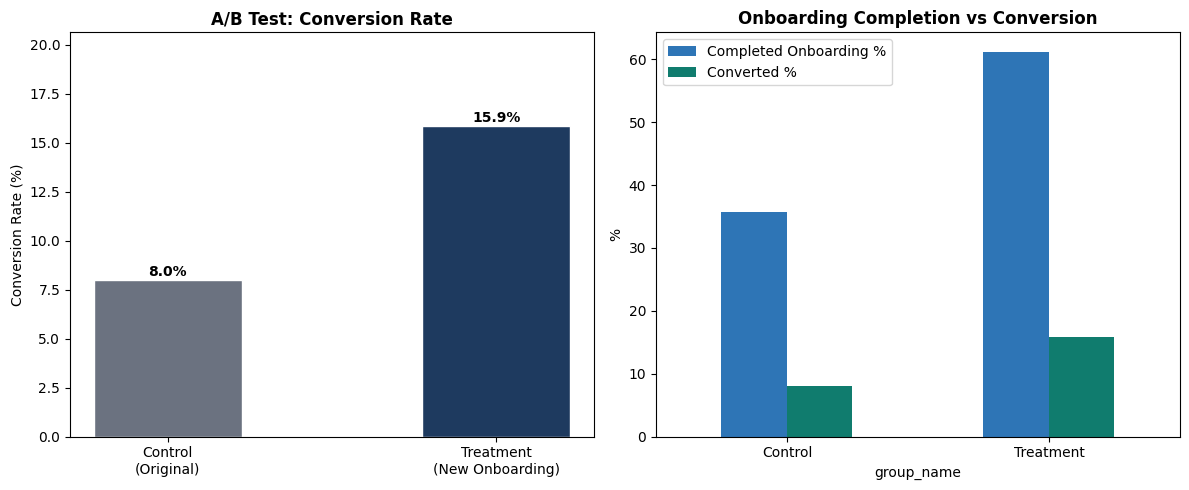

In [5]:
# A/B Hypothesis Testing (Chi-Square + Z-Test)
# ─────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, norm

ab = pd.read_csv('ab_test_results.csv')

# ── SPLIT GROUPS ─────────────────────────────────────────────────────────
ctrl = ab[ab['group_name'] == 'Control']
trtm = ab[ab['group_name'] == 'Treatment']

ctrl_conv = ctrl['converted'].sum()
trtm_conv = trtm['converted'].sum()
ctrl_n    = len(ctrl)
trtm_n    = len(trtm)
ctrl_rate = ctrl_conv / ctrl_n
trtm_rate = trtm_conv / trtm_n

print('═'*55)
print('          A/B TEST RESULTS SUMMARY')
print('═'*55)
print(f'Control   : {ctrl_conv}/{ctrl_n} → {ctrl_rate*100:.2f}%')
print(f'Treatment : {trtm_conv}/{trtm_n} → {trtm_rate*100:.2f}%')
print(f'Lift      : +{(trtm_rate - ctrl_rate)*100:.2f} pp')
print(f'Relative  : +{((trtm_rate/ctrl_rate)-1)*100:.1f}%')
print()

# ── CHI-SQUARE TEST ──────────────────────────────────────────────────────
contingency = [[ctrl_conv, ctrl_n - ctrl_conv],
               [trtm_conv, trtm_n - trtm_conv]]
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f'Chi-Square Statistic : {chi2:.4f}')
print(f'P-Value              : {p_chi:.4f}')
print(f'Degrees of Freedom   : {dof}')
print(f'Result               : {"SIGNIFICANT ✓" if p_chi < 0.05 else "Not significant"}')

# ── Z-TEST ───────────────────────────────────────────────────────────────
pooled_p = (ctrl_conv + trtm_conv) / (ctrl_n + trtm_n)
se = np.sqrt(pooled_p * (1 - pooled_p) * (1/ctrl_n + 1/trtm_n))
z  = (trtm_rate - ctrl_rate) / se
p_z = 1 - norm.cdf(abs(z))
print(f'\nZ-Score              : {z:.4f}')
print(f'One-tailed P-Value   : {p_z:.4f}')

# ── CONFIDENCE INTERVAL ──────────────────────────────────────────────────
diff = trtm_rate - ctrl_rate
ci_low  = diff - 1.96 * se
ci_high = diff + 1.96 * se
print(f'\n95% CI for lift      : [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')

# ── VISUALISE ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
groups = ['Control\n(Original)', 'Treatment\n(New Onboarding)']
rates  = [ctrl_rate*100, trtm_rate*100]
colors = ['#6B7280', '#1E3A5F']
bars = axes[0].bar(groups, rates, color=colors, width=0.45, edgecolor='white')
axes[0].set_title('A/B Test: Conversion Rate', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, max(rates)*1.3)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                 f'{b.get_height():.1f}%', ha='center', fontweight='bold')

# Onboarding completion
comp = ab.groupby('group_name')[['completed_onboarding','converted']].mean()*100
comp.plot(kind='bar', ax=axes[1], color=['#2E75B6','#107C6E'], width=0.5)
axes[1].set_title('Onboarding Completion vs Conversion', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].set_xticklabels(comp.index, rotation=0)
axes[1].legend(['Completed Onboarding %', 'Converted %'])

plt.tight_layout()
plt.savefig('fig_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()


=== LOGISTIC REGRESSION ===
Accuracy : 100.00%
ROC-AUC  : 1.0000
              precision    recall  f1-score   support

  No Convert       1.00      1.00      1.00       880
     Convert       1.00      1.00      1.00       120

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


=== RANDOM FOREST ===
Accuracy : 100.00%
ROC-AUC  : 1.0000


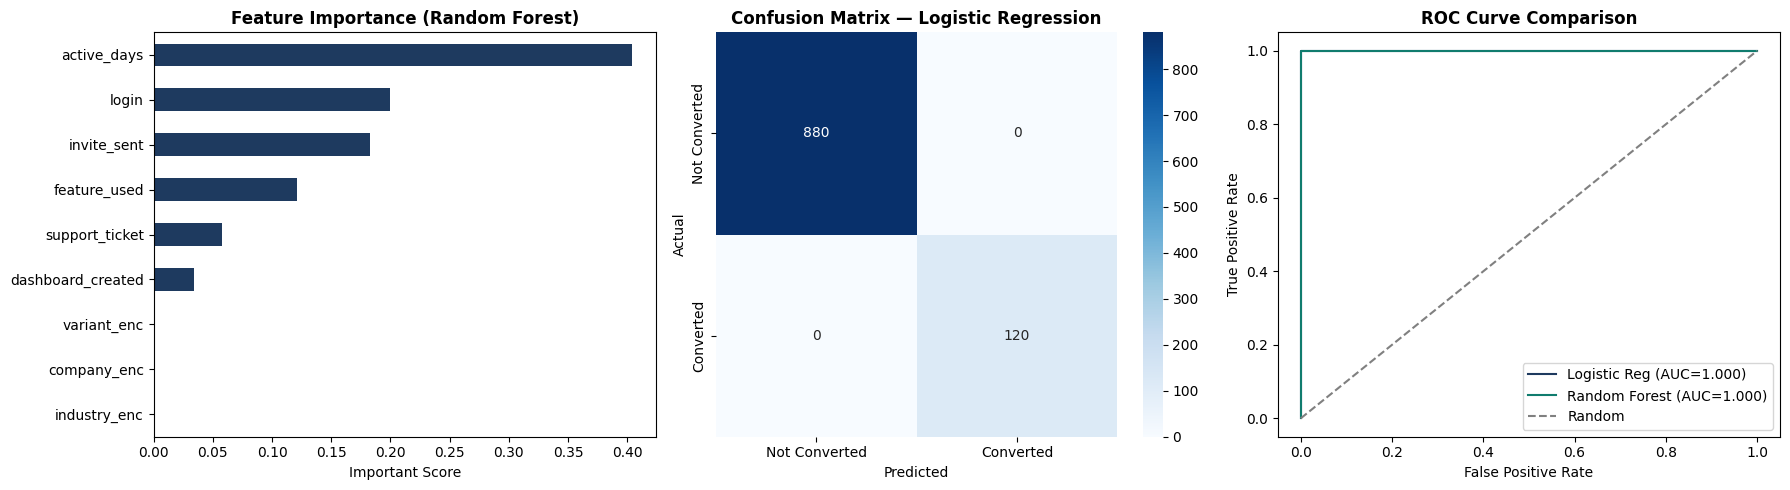


✅ scored_users.csv — now i will use it for Power BI


In [9]:
# Machine Learning
# Logistic Regression + Random Forest — Conversion Probability Scoring
# ─────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

# ── 1. BUILD FEATURE TABLE ────────────────────────────────────────────────
users  = pd.read_csv('users.csv', parse_dates=['signup_date'])
trials = pd.read_csv('trials.csv')
events = pd.read_csv('events.csv')

# Pivot events into per-user feature columns
ev_pivot = events.pivot_table(
    index='user_id', columns='event_type', values='event_count',
    aggfunc='sum', fill_value=0
).reset_index()
ev_pivot.columns.name = None

# Active days feature
active_days = events.groupby('user_id')['event_date'].nunique().reset_index()
active_days.columns = ['user_id','active_days']

# Merge all
df = (trials.merge(users, on='user_id')
           .merge(ev_pivot, on='user_id', how='left')
           .merge(active_days, on='user_id', how='left')
           .fillna(0))

# ── 2. ENCODE CATEGORICALS ────────────────────────────────────────────────
le = LabelEncoder()
df['industry_enc']  = le.fit_transform(df['industry'])
df['company_enc']   = le.fit_transform(df['company_size'])
df['variant_enc']   = (df['onboarding_variant'] == 'Treatment').astype(int)

FEATURES = ['active_days','login','feature_used','invite_sent',
            'dashboard_created','support_ticket',
            'industry_enc','company_enc','variant_enc']
# Keep only cols that exist
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES]
y = df['converted']

# ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── 4. LOGISTIC REGRESSION ────────────────────────────────────────────────
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr  = lr.predict(X_test_s)
y_prob_lr  = lr.predict_proba(X_test_s)[:,1]

print('=== LOGISTIC REGRESSION ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['No Convert','Convert']))

# ── 5. RANDOM FOREST ─────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('\n=== RANDOM FOREST ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')

# ── 6. FEATURE IMPORTANCE ─────────────────────────────────────────────────
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Feature Importance
fi.plot(kind='barh', ax=axes[0], color='#1E3A5F')
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Important Score')
axes[0].invert_yaxis()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Converted','Converted'],
            yticklabels=['Not Converted','Converted'])
axes[1].set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test,y_prob_lr):.3f})', color='#1E3A5F')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test,y_prob_rf):.3f})', color='#107C6E')
axes[2].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. EXPORT SCORED USERS ───────────────────────────────────────────────
df['conversion_probability'] = lr.predict_proba(scaler.transform(X[FEATURES]))[:,1].round(4)
df['risk_tier'] = pd.cut(df['conversion_probability'],
                          bins=[0, 0.10, 0.25, 0.50, 1.0],
                          labels=['Very Low','Low','Medium','High'])

output = df[['user_id','conversion_probability','risk_tier','converted']]
output.to_csv('scored_users.csv', index=False)
print('\n✅ scored_users.csv — now i will use it for Power BI')
